# Régression : quel prix pratiquer, et quels arrondissements rapportent le plus ?

*Un investisseur veut acheter un bien pour le louer sur Airbnb. Quel prix peut-il pratiquer, et quels quartiers offrent le meilleur retour sur investissement ?*

1. Ingestion de la base SQLite dans des DataFrames pandas
2. Filtrage des annonces (marché observé de la courte durée)
3. Suppression des variables inutiles, dont latitude et longitude
4. One-hot encoding de l'arrondissement et du type de bien
5. Deux régressions linéaires : prix par nuit et revenu annuel
6. Prix prévu pour un studio, un T2 et un T3 dans chaque arrondissement
7. ROI net simplifié (gestion par soi-même), avec le prix d'achat DVF

In [3]:
import os
import sqlite3
from pathlib import Path

from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Paths come from the project-root .env; relative paths are from the project root.
ROOT = Path('..')
load_dotenv(ROOT / '.env')
DATABASE = ROOT / os.getenv('DATABASE', 'ingestion/paris.sqlite')
BLUE, ORANGE = '#2a78d6', '#eb6834'

with sqlite3.connect(f'file:{DATABASE.as_posix()}?mode=ro', uri=True) as db:
    airbnb = pd.read_sql_query('SELECT * FROM airbnb_listings', db)
    sales = pd.read_sql_query('SELECT * FROM paris_property_sales', db)
    names = dict(db.execute('SELECT arrondissement, name FROM arrondissements'))
print(f'Airbnb : {airbnb.shape[0]:,} annonces, DVF : {sales.shape[0]:,} lignes')

Airbnb : 77,679 annonces, DVF : 84,440 lignes


## 1. Filtrage des annonces

On garde ce qu'un investisseur mettrait en location : logement entier, actif (au moins un avis sur 12 mois), séjour minimum de moins de 30 nuits.
Le prix est un devis pour fin juin – début juillet 2026. On ne garde que les devis de 7 nuits au plus : au-delà, le prix par nuit baisse fortement.

In [4]:
airbnb['quote_nights'] = (pd.to_datetime(airbnb['price_quote_checkout_date'])
                          - pd.to_datetime(airbnb['price_quote_checkin_date'])).dt.days
market = airbnb[(airbnb['room_type'] == 'Entire home/apt')
                & (airbnb['number_of_reviews_ltm'] > 0)
                & (airbnb['minimum_nights'] < 30)]
# Occupancy is measured before the price filter: fully booked flats have no quote.
occupancy = market.groupby('arrondissement')['estimated_occupancy_l365d'].median()
listings = market[(market['quote_currency'] == 'EUR')
                  & (market['price_quote_price_per_night'] > 0)
                  & (market['quote_nights'] <= 7)].copy()
print(f'{len(market):,} logements actifs en courte durée, dont {len(listings):,} avec un devis exploitable')

33,655 logements actifs en courte durée, dont 27,454 avec un devis exploitable


## 2. Suppression des variables inutiles

On garde ce qu'on connaît avant d'acheter : **taille** (capacité, chambres, salles de bain), **type de bien** et **arrondissement**, plus les deux cibles.
Tout le reste part : identifiants, textes, dates, latitude et longitude (l'arrondissement suffit), avis et hôte (inconnus avant l'achat), lits (doublon de la capacité), autres colonnes de prix ou de revenu (elles contiennent la réponse).

Deux corrections : les studios n'ont pas de nombre de chambres dans la source (jamais 0), on met 0 ; les salles de bain manquantes sont relues dans le texte (« 1 bath »).

In [5]:
SIZE = ['accommodates', 'bedrooms', 'bathrooms']
TARGETS = {'Prix par nuit': 'price_quote_price_per_night', 'Revenu annuel': 'estimated_revenue_l365d'}

listings['bedrooms'] = listings['bedrooms'].fillna(0)
listings['bathrooms'] = listings['bathrooms'].fillna(
    pd.to_numeric(listings['bathrooms_text'].str.extract(r'([\d.]+)')[0], errors='coerce'))
# Rare property types are grouped so that each one-hot column has enough listings.
common = listings['property_type'].value_counts().loc[lambda n: n >= 100].index
listings['property_type'] = listings['property_type'].where(listings['property_type'].isin(common), 'Autre')

columns = SIZE + ['property_type', 'arrondissement'] + list(TARGETS.values())
print('Colonnes retirées :', ', '.join(c for c in listings.columns if c not in columns))
data = listings[columns].dropna()
print(f'\n{len(data):,} annonces × {data.shape[1]} colonnes')

Colonnes retirées : id, listing_url, scrape_id, last_scraped, source, name, description, neighborhood_overview, picture_url, host_id, host_url, host_profile_id, host_profile_url, host_name, host_since, hosts_time_as_user_years, hosts_time_as_user_months, hosts_time_as_host_years, hosts_time_as_host_months, host_location, host_about, host_response_time, host_response_rate, host_acceptance_rate, host_is_superhost, host_thumbnail_url, host_picture_url, host_neighbourhood, host_listings_count, host_total_listings_count, host_verifications, host_has_profile_pic, host_identity_verified, neighbourhood, neighbourhood_cleansed, neighbourhood_group_cleansed, latitude, longitude, room_type, bathrooms_text, beds, amenities, price, price_quote_checkin_date, price_quote_checkout_date, price_quote_total_price, price_quote_raw, minimum_nights, maximum_nights, minimum_minimum_nights, maximum_minimum_nights, minimum_maximum_nights, maximum_maximum_nights, minimum_nights_avg_ntm, maximum_nights_avg_ntm, 

## 3. One-hot encoding

L'arrondissement et le type de bien deviennent des colonnes 0/1. Une modalité de chaque variable sert de référence et n'a pas de colonne, sinon les colonnes seraient redondantes pour la régression linéaire :
le **11e** (prix médian proche de celui de Paris) et l'**appartement classique** (*Entire rental unit*).

In [6]:
X = pd.get_dummies(data[SIZE + ['property_type', 'arrondissement']],
                   columns=['arrondissement', 'property_type'], dtype=int)
X = X.drop(columns=['arrondissement_11', 'property_type_Entire rental unit'])
X.head()

,accommodates,bedrooms,bathrooms,arrondissement_1,arrondissement_2,arrondissement_3,arrondissement_4,arrondissement_5,arrondissement_6,arrondissement_7,...,arrondissement_17,arrondissement_18,arrondissement_19,arrondissement_20,property_type_Autre,property_type_Entire condo,property_type_Entire home,property_type_Entire loft,property_type_Entire serviced apartment,property_type_Entire townhouse
0,2,1.0,1.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,2.0,1.0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
3,2,1.0,1.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,6,2.0,1.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2,1.0,1.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Deux régressions linéaires

Prix et revenus sont très étalés : on retire 1 % des valeurs extrêmes de chaque côté et on modélise leur **logarithme**. Un coefficient *c* se lit alors comme un effet de (e<sup>c</sup> − 1) × 100 %.
Entraînement sur 80 % des annonces, évaluation sur les 20 % restantes.

In [7]:
models = {}
for label, target in TARGETS.items():
    low, high = data[target].quantile([0.01, 0.99])
    rows = data[target].between(low, high)
    X_train, X_test, y_train, y_test = train_test_split(
        X[rows], np.log(data.loc[rows, target]), test_size=0.2, random_state=42)
    models[label] = LinearRegression().fit(X_train, y_train)
    predicted = models[label].predict(X_test)
    print(f'{label} : R² = {r2_score(y_test, predicted):.2f}, '
          f'erreur moyenne = {mean_absolute_error(np.exp(y_test), np.exp(predicted)):,.0f} €')

Prix par nuit : R² = 0.61, erreur moyenne = 83 €
Revenu annuel : R² = 0.19, erreur moyenne = 22,286 €


,Prix par nuit,Revenu annuel
accommodates,10.9,20.7
bedrooms,15.3,-9.9
bathrooms,19.0,24.4
property_type_Autre,7.5,12.1
property_type_Entire condo,-0.8,6.8
property_type_Entire home,-1.6,-12.8
property_type_Entire loft,2.9,17.7
property_type_Entire serviced apartment,21.8,35.5
property_type_Entire townhouse,4.6,-8.3


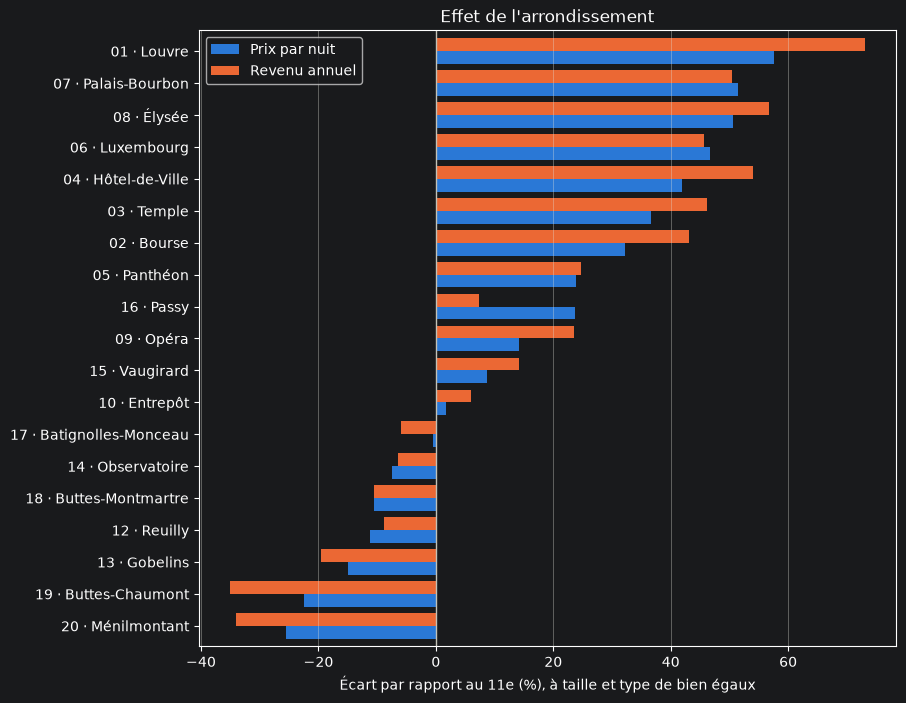

In [8]:
# Effect of each variable, in % (per extra unit for the size variables).
effects = pd.DataFrame({label: (np.exp(model.coef_) - 1) * 100 for label, model in models.items()},
                       index=X.columns)
display(effects.drop(index=effects.filter(like='arrondissement_', axis=0).index).round(1))

by_area = effects.filter(like='arrondissement_', axis=0)
by_area.index = [f"{n:02} · {names[n]}" for n in by_area.index.str.split('_').str[1].astype(int)]
ax = by_area.sort_values('Prix par nuit').plot.barh(figsize=(9, 8), color=[BLUE, ORANGE], width=0.8)
ax.axvline(0, color='#c3c2b7', linewidth=1)
ax.grid(axis='x', color='#e1e0d9')
ax.set_xlabel('Écart par rapport au 11e (%), à taille et type de bien égaux')
ax.set_title("Effet de l'arrondissement")
plt.show()

## 5. Quel prix pratiquer ?

Prix par nuit prévu pour un bien type dans chaque arrondissement. Le bien type prend la capacité et le nombre de salles de bain médians des annonces qui ont le même nombre de chambres (studio = 0, T2 = 1, T3 = 2).
C'est un prix médian : l'erreur moyenne du modèle donne l'ordre de grandeur de l'incertitude.

In [9]:
TYPOLOGIES = {'Studio': 0, 'T2': 1, 'T3': 2}  # Airbnb bedrooms; DVF main rooms = bedrooms + 1
profiles = pd.DataFrame([data.loc[data['bedrooms'] == b, SIZE].median() for b in TYPOLOGIES.values()],
                        index=pd.Index(TYPOLOGIES, name='Typologie'))
display(profiles)

grid = profiles.reset_index().merge(pd.DataFrame({'arrondissement': range(1, 21)}), how='cross')
grid['property_type'] = 'Entire rental unit'
X_grid = pd.get_dummies(grid[SIZE + ['property_type', 'arrondissement']],
                        columns=['arrondissement', 'property_type'], dtype=int).reindex(columns=X.columns, fill_value=0)
for label, model in models.items():
    grid[label] = np.exp(model.predict(X_grid))
grid['Arrondissement'] = [f'{n:02} · {names[n]}' for n in grid['arrondissement']]
grid.pivot(index='Arrondissement', columns='Typologie', values='Prix par nuit').style.format('{:.0f} €').background_gradient(cmap='Blues')

,accommodates,bedrooms,bathrooms
Typologie,,,
Studio,2.0,0.0,1.0
T2,2.0,1.0,1.0
T3,4.0,2.0,1.0


Typologie,Studio,T2,T3
Arrondissement,,,
01 · Louvre,238 €,275 €,390 €
02 · Bourse,200 €,231 €,327 €
03 · Temple,207 €,238 €,338 €
04 · Hôtel-de-Ville,215 €,248 €,351 €
05 · Panthéon,187 €,216 €,307 €
06 · Luxembourg,222 €,256 €,363 €
07 · Palais-Bourbon,229 €,264 €,375 €
08 · Élysée,228 €,263 €,373 €
09 · Opéra,173 €,199 €,282 €


## 6. Prix d'achat (DVF)

DVF n'a pas d'identifiant de vente : les lignes qui partagent date, nature, prix et commune sont regroupées en une vente.
On garde les ventes d'**un seul appartement** (une cave ou un parking peuvent être inclus) de 1 à 3 pièces : studio = 1 pièce, T2 = 2, T3 = 3.

In [10]:
sales['flat'] = sales['code_type_local'] == 2
sales['other'] = sales['code_type_local'].isin([1, 4])  # house or commercial premises
per_sale = sales.groupby(['date_mutation', 'nature_mutation', 'valeur_fonciere', 'code_commune']).agg(
    flats=('flat', 'sum'), other=('other', 'sum'), rooms=('nombre_pieces_principales', 'max'),
    surface=('surface_reelle_bati', 'max'), arrondissement=('arrondissement', 'first')).reset_index()
single = per_sale[(per_sale['flats'] == 1) & (per_sale['other'] == 0) & (per_sale['nature_mutation'] == 'Vente')
                  & per_sale['rooms'].between(1, 3) & (per_sale['surface'] >= 9)].copy()
price_m2 = single['valeur_fonciere'] / single['surface']
single = single[price_m2.between(*price_m2.quantile([0.01, 0.99]))]
single['Typologie'] = single['rooms'].map({1: 'Studio', 2: 'T2', 3: 'T3'})
purchase = single.groupby(['arrondissement', 'Typologie']).agg(
    price=('valeur_fonciere', 'median'), surface=('surface', 'median'), sales=('valeur_fonciere', 'size')).reset_index()
print(f"{len(single):,} ventes retenues, au moins {purchase['sales'].min()} par arrondissement et typologie")

23,345 ventes retenues, au moins 45 par arrondissement et typologie


## 7. Retour sur investissement net

Le revenu annuel est calculé de deux façons, pour vérifier que le classement tient :
- **a** : prix prévu × occupation médiane de l'arrondissement ;
- **b** : revenu prévu directement par la 2e régression.

ROI net = (revenu − frais annuels) / (prix d'achat + notaire + ameublement). Les frais sont des **hypothèses** pour un investisseur qui gère lui-même : à modifier ci-dessous.

Accord entre les classements a et b (Spearman) : 0.91


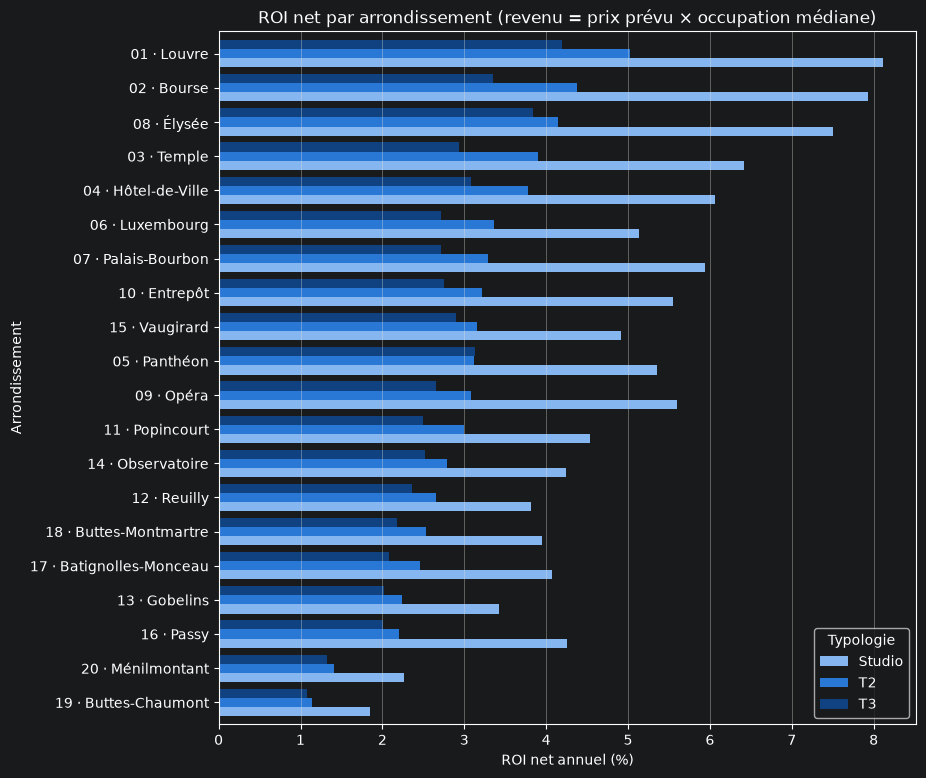

,Arrondissement,Typologie,Prix d'achat,Surface (m²),Prix par nuit,Revenu a (prix × occupation),Revenu b (modèle),ROI a (%),ROI b (%)
0,01 · Louvre,Studio,250000.0,21.0,238.3,27161.6,25897.4,8.1,7.7
1,02 · Bourse,Studio,210000.0,20.0,200.0,22798.5,21428.8,7.9,7.4
7,08 · Élysée,Studio,255000.0,23.0,227.6,25951.5,23462.9,7.5,6.7
2,03 · Temple,Studio,241115.0,22.0,206.7,21494.2,21893.1,6.4,6.6
3,04 · Hôtel-de-Ville,Studio,269635.0,20.0,214.7,22328.7,23059.9,6.1,6.3
6,07 · Palais-Bourbon,Studio,261000.0,22.0,228.9,21519.0,22526.4,5.9,6.3
8,09 · Opéra,Studio,199000.0,20.0,172.5,16215.7,18502.4,5.6,6.6
9,10 · Entrepôt,Studio,175000.0,19.0,153.7,14449.0,15859.7,5.5,6.2
4,05 · Panthéon,Studio,230500.0,20.0,187.4,17615.9,18681.0,5.4,5.7
5,06 · Luxembourg,Studio,292000.0,22.0,221.9,20855.5,21798.7,5.1,5.4


In [12]:
# Assumptions for a self-managed flat, not data: adjust them here.
NOTARY_FEES = 0.08        # share of the purchase price
FURNISHING_EUR_M2 = 250   # one-off furnishing
AIRBNB_FEE = 0.03         # host service fee, share of revenue
SUPPLIES = 0.05           # linen, consumables, small repairs, share of revenue
CHARGES_EUR_M2 = 60       # co-ownership charges + property tax, per m² and year
FIXED_EUR = 1_400         # electricity, internet, insurance, per year

roi = grid.merge(purchase, on=['arrondissement', 'Typologie'])
roi['Revenu a (prix × occupation)'] = roi['Prix par nuit'] * roi['arrondissement'].map(occupancy)
investment = roi['price'] * (1 + NOTARY_FEES) + roi['surface'] * FURNISHING_EUR_M2
REVENUES = {'ROI a (%)': 'Revenu a (prix × occupation)', 'ROI b (%)': 'Revenu annuel'}
for name, revenue in REVENUES.items():
    costs = roi[revenue] * (AIRBNB_FEE + SUPPLIES) + roi['surface'] * CHARGES_EUR_M2 + FIXED_EUR
    roi[name] = 100 * (roi[revenue] - costs) / investment
print('Accord entre les classements a et b (Spearman) :', round(roi[list(REVENUES)].corr('spearman').iloc[0, 1], 2))

table = roi.pivot(index='Arrondissement', columns='Typologie', values='ROI a (%)').sort_values('T2')
ax = table.plot.barh(figsize=(9, 9), color=['#86b6ef', '#2a78d6', '#104281'], width=0.8)
ax.grid(axis='x', color='#e1e0d9')
ax.set_xlabel('ROI net annuel (%)')
ax.set_title('ROI net par arrondissement (revenu = prix prévu × occupation médiane)')
plt.show()

roi.sort_values('ROI a (%)', ascending=False)[
    ['Arrondissement', 'Typologie', 'price', 'surface', 'Prix par nuit', 'Revenu a (prix × occupation)', 'Revenu annuel', 'ROI a (%)', 'ROI b (%)']
].rename(columns={'price': "Prix d'achat", 'surface': 'Surface (m²)', 'Revenu annuel': 'Revenu b (modèle)'}).head(10).round(1)

## Limites

- Les prix sont des devis de **haute saison** (fin juin – juillet) : le revenu annuel est surestimé en valeur absolue.
- L'occupation est une **estimation Inside Airbnb** à partir du nombre d'avis, plafonnée à 255 nuits.
- Le modèle de revenu est bien moins précis que celui du prix (voir les R²) : l'occupation varie beaucoup d'une annonce à l'autre pour des raisons absentes des variables.
- **Marché observé** : la réglementation parisienne (changement d'usage, 90 nuits pour une résidence principale) n'est pas appliquée. Le ROI est une borne haute.
- DVF : regroupement approximatif des lignes en ventes ; caves et parkings éventuels sont inclus dans le prix.
- Les frais sont des hypothèses, pas des données.
- Les prévisions sont des valeurs médianes (exponentielle d'une prédiction faite en log).